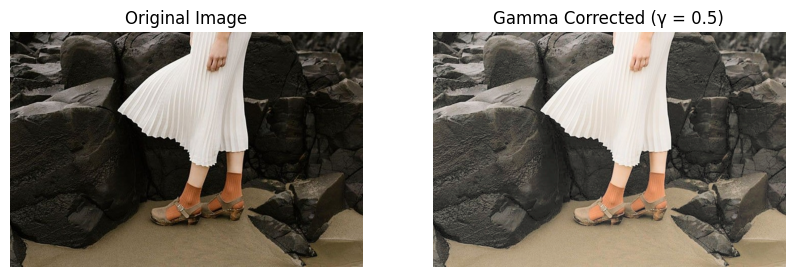

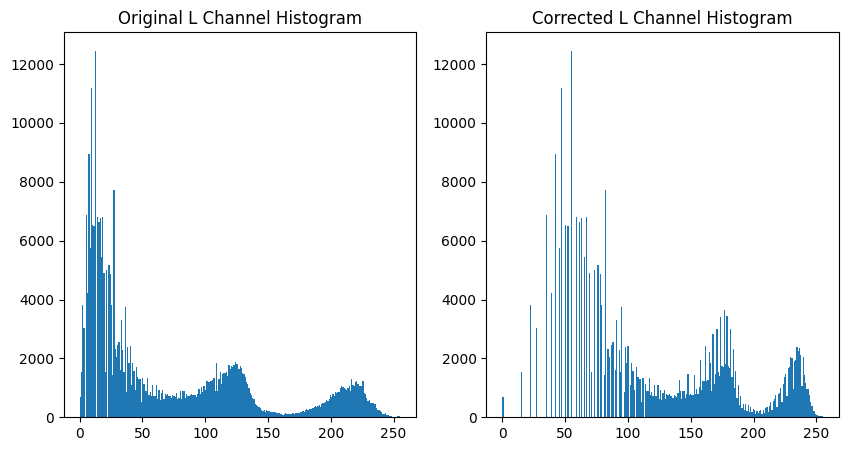

In [6]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def gamma_correction(channel, gamma):
    #Normalize to [0,1]
    norm = channel / 255.0

    #Apply gamma correction
    corrected = np.power(norm, gamma)

    #Convert back to [0,255]
    return np.uint8(corrected * 255)


#Load image
img = cv.imread("/content/Input_figure2.jpg")

if img is None:
    raise FileNotFoundError("Image not found. Check the file path.")

#Convert original image to RGB for display
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

#Convert image to LAB color space
lab = cv.cvtColor(img, cv.COLOR_BGR2LAB)

#Split LAB channels
L, A, B = cv.split(lab)

#Apply gamma correction only on L channel
gamma = 0.5
L_corrected = gamma_correction(L, gamma)

#Merge corrected L with original A and B
lab_corrected = cv.merge((L_corrected, A, B))

#Convert corrected LAB image back to BGR first
img_corrected_bgr = cv.cvtColor(lab_corrected, cv.COLOR_LAB2BGR)

#Convert corrected image to RGB for display
img_corrected_rgb = cv.cvtColor(img_corrected_bgr, cv.COLOR_BGR2RGB)

#Display images
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_corrected_rgb)
plt.title(f"Gamma Corrected (γ = {gamma})")
plt.axis("off")

plt.show()

#Save corrected image
cv.imwrite("output_gamma_lab.png", img_corrected_bgr)

# ----------- Histograms -----------

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.hist(L.ravel(), bins=256, range=(0,255))
plt.title("Original L Channel Histogram")
plt.savefig("hist_original_L.png")

plt.subplot(1,2,2)
plt.hist(L_corrected.ravel(), bins=256, range=(0,255))
plt.title("Corrected L Channel Histogram")
plt.savefig("hist_corrected_L.png")

plt.show()
